## Data Analytics Using Python: Air Quality Index Prediction
By: **Sri Charan** (240660) | Class: **CSE-3**

##  Step 1: Problem Definition & Dataset Selection

### 1. Real-World Dataset Choice

The dataset chosen is the **Air Quality Index Dataset**, which contains daily measurements of major pollutant concentrations across multiple cities over several years. This is a vital real-world dataset as air quality directly impacts public health.

### 2. Clearly Define Objective

The objective of this project is to develop and evaluate a **Linear Regression model** to **predict the continuous numerical Air Quality Index (AQI) score** based on the measured concentrations of various atmospheric pollutants (like $\text{PM2.5}$, $\text{NO}_2$, $\text{SO}_2$, etc.). This falls under a **Regression** problem type.

### 3.  Dataset Source

* **Source:** **Kaggle**
* **Description:** The dataset typically includes daily measurements for several Indian cities, spanning from 2015 onwards. Key columns include a `Date` column, the final `AQI` score, and concentrations of various pollutants like $\text{PM2.5}$, $\text{PM10}$, $\text{NO}_2$, $\text{SO}_2$, $\text{CO}$, and $\text{O}_3$.
* **Data Set** `#https://www.kaggle.com/code/anjusunilkumar/air-quality-index-prediction?select=city_day.csv`

## Importing Required Libraries
We start by importing essential libraries for data manipulation, visualization, and model training.

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.linear_model import LinearRegression

## Loading and Exploring the Dataset
We load the dataset and perform initial exploration to understand its structure and characteristics.

In [25]:
# Load Dataset
file_path = "city_day.csv"  #https://www.kaggle.com/code/anjusunilkumar/air-quality-index-prediction?select=city_day.csv
df = pd.read_csv(file_path)

Adding the Pb Value in a New Column as its required in calcuation of AQI

In [26]:

pb_imputation_value = 0.50
df['Pb'] = pb_imputation_value

## Getting the Total numer of rows & columns

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
 16  Pb          29531 non-null  float64
dtypes: float64(14), object(3)
memory usage: 3.8+ MB


## Step 2:Data Cleaning and Preparation
This step involves handling missing values, encoding categorical features, and normalizing numerical features.

In [28]:
# Che+ck the total null values
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
Pb                0
dtype: int64

## Handling missing values
Drop rows where AQI is missing, as it's our target variable

In [29]:
df = df.dropna(subset=['AQI'])

### Handle Missing Data with Median Imputation

In [30]:
median_values = df.select_dtypes(include=np.number).median()
df = df.fillna(median_values)


###     Maps a numerical AQI score to its corresponding descriptive health category (bucket).


In [31]:
def get_aqi_bucket(aqi_value):
    
    if pd.isna(aqi_value):
        return np.nan # Keep the bucket NaN if the AQI calculation failed
    elif aqi_value <= 50:
        return 'Good'
    elif aqi_value <= 100:
        return 'Satisfactory'
    elif aqi_value <= 200:
        return 'Moderate'
    elif aqi_value <= 300:
        return 'Poor'
    elif aqi_value <= 400:
        return 'Very Poor'
    elif aqi_value <= 500:
        return 'Severe'
    else:
        return 'Hazardous' # For AQI > 500

df['AQI_Bucket'] = df['AQI'].apply(get_aqi_bucket)
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Pb
28,Ahmedabad,2015-01-29,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.000,3.14,209.0,Poor,0.5
29,Ahmedabad,2015-01-30,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.000,4.81,328.0,Very Poor,0.5
30,Ahmedabad,2015-01-31,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.010,7.67,514.0,Hazardous,0.5
31,Ahmedabad,2015-02-01,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.040,25.87,782.0,Hazardous,0.5
32,Ahmedabad,2015-02-02,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.060,35.61,914.0,Hazardous,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.070,0.73,41.0,Good,0.5
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.210,0.38,70.0,Satisfactory,0.5
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.010,0.00,68.0,Satisfactory,0.5
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.000,0.00,54.0,Satisfactory,0.5


###  Safe Column Dropping and Data Cleaning


In [32]:
# List of columns we want to drop
drop_columns = ['City', 'Date', 'AQI_Bucket']

# Check which columns actually exist in the DataFrame
existing_columns = [col for col in drop_columns if col in df.columns]

# Drop only the columns that are found
if existing_columns:
    df = df.drop(columns=existing_columns)
    print(f"Dropped columns: {existing_columns}")
else:
    print("Columns 'City', 'Date', 'AQI_Bucket' already dropped or do not exist.")

Dropped columns: ['City', 'Date', 'AQI_Bucket']


## Step 3: Exploratory Data Analysis (EDA)
We visualize the data to identify patterns, correlations, and important features.

In [73]:
data = df.copy()

data = data.dropna(subset=['AQI'])     
X = data.drop('AQI', axis=1)
y = data['AQI']


### Descriptive Statistics Summary
This summary provides a quantitative overview of the dataset's central tendency, dispersion, and shape (like mean, median, and standard deviation) for all numerical columns. It is essential for identifying data characteristics, checking for outliers, and assessing the need for scaling or transformation before model training.

In [68]:
# Generates the table required for step 3
descriptive_stats = numerical_df.describe().T
(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
PM2.5,24850.0,66.966637,62.283431,0.04,29.56,48.785,79.5075,914.94
PM10,24850.0,112.102860,76.325808,0.03,71.78,96.180,122.9575,917.08
NO,24850.0,17.502312,22.266346,0.03,5.72,9.910,19.7100,390.68
NO2,24850.0,28.870163,24.447523,0.01,12.09,22.100,37.9100,362.21
NOx,24850.0,31.645675,29.629575,0.00,14.03,23.680,38.1700,378.24
NH3,24850.0,21.865639,22.460343,0.01,11.28,16.310,24.7100,352.89
CO,24850.0,2.319923,7.014082,0.00,0.59,0.930,1.4600,175.81
SO2,24850.0,14.237723,17.233456,0.01,5.79,9.220,14.8900,186.08
O3,24850.0,34.793934,21.378711,0.01,19.64,31.250,45.3975,257.73
Benzene,24850.0,3.150167,14.870955,0.00,0.34,1.290,2.8500,455.03


## 1. Box Plots for Pollutant Outlier Detection
Box Plots for Pollutant Outlier DetectionThis plot uses box plots to visually summarize the distribution of your pollutant concentration data across all recorded samples.

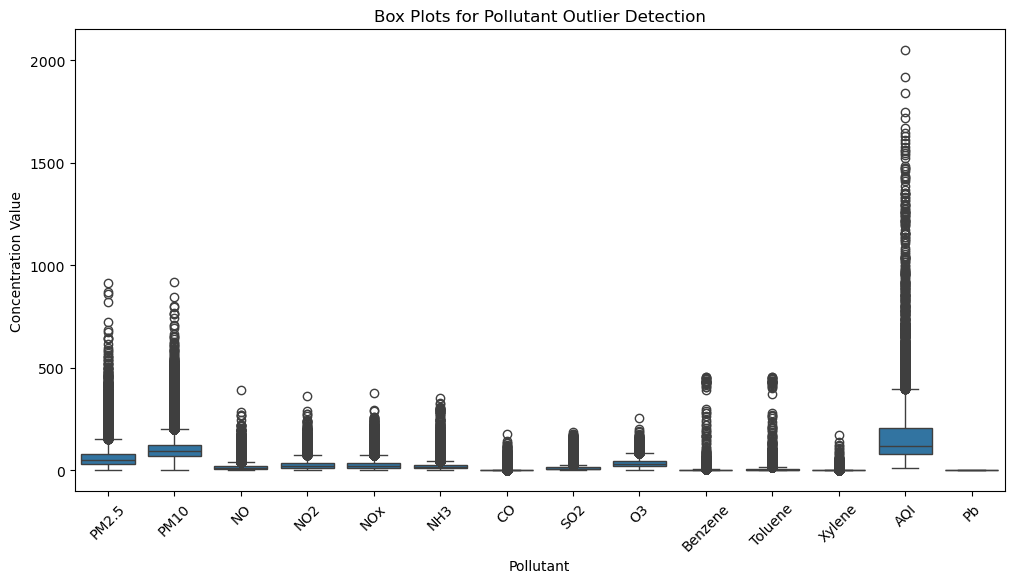

In [67]:
import numpy as np # Needed for np.number
import matplotlib.pyplot as plt
import seaborn as sns

# --- FIX: Define numerical_df by selecting only numerical columns ---
# Assuming your main DataFrame is named 'df'
try:
    numerical_df = df.select_dtypes(include=np.number)
except NameError:
    print("Error: The main DataFrame 'df' is not defined. Please load your data first.")
    exit()

plt.figure(figsize=(12, 6))
# Melt the DataFrame to plot all pollutants in a single boxplot graph
sns.boxplot(data=numerical_df.melt(), x='variable', y='value')
plt.title('Box Plots for Pollutant Outlier Detection')
plt.xlabel('Pollutant')
plt.ylabel('Concentration Value')
plt.xticks(rotation=45)
plt.show()

### 2.Univariate Analysis: Pollutant & AQI Distribution

It generates a single figure containing six separate Histograms with KDE overlays to visualize the individual frequency distribution, skewness, and range of five key pollutants and the target AQI score. This helps you quickly assess the underlying statistical nature of your data before modeling.

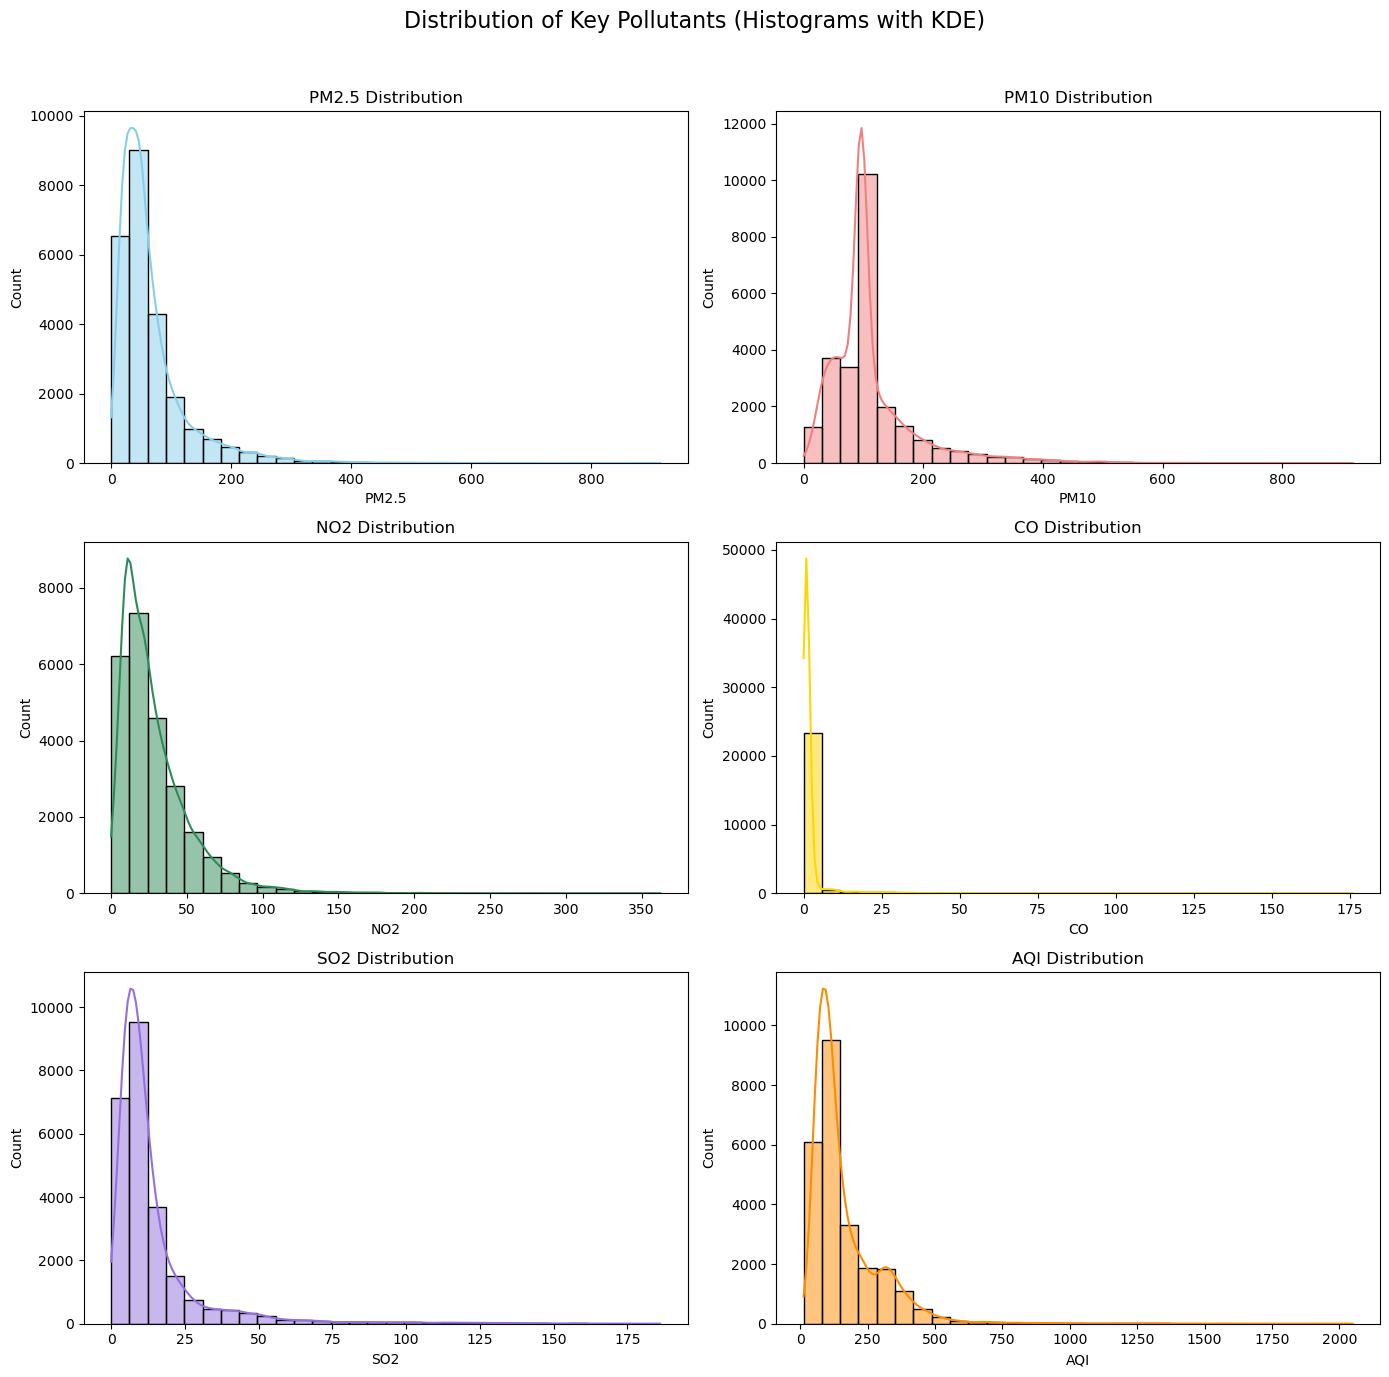

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 3x2 grid (6 plots)
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle("Distribution of Key Pollutants (Histograms with KDE)", fontsize=16)

# --- Plot 1: PM2.5 Distribution (Already correct) ---
sns.histplot(df['PM2.5'], kde=True, ax=axes[0, 0], bins=30, color='skyblue')
axes[0, 0].set_title("PM2.5 Distribution")

# --- Plot 2: PM10 Distribution (Changed from original) ---
sns.histplot(df['PM10'], kde=True, ax=axes[0, 1], bins=30, color='lightcoral')
axes[0, 1].set_title("PM10 Distribution")

# --- Plot 3: NO2 Distribution (Changed from original) ---
sns.histplot(df['NO2'], kde=True, ax=axes[1, 0], bins=30, color='seagreen')
axes[1, 0].set_title("NO2 Distribution")

# --- Plot 4: CO Distribution (Changed from Boxplot) ---
sns.histplot(df['CO'], kde=True, ax=axes[1, 1], bins=30, color='gold')
axes[1, 1].set_title("CO Distribution")

# --- Plot 5: SO2 Distribution (Already correct) ---
sns.histplot(df['SO2'], kde=True, ax=axes[2, 0], bins=30, color='mediumpurple')
axes[2, 0].set_title("SO2 Distribution")

# --- Plot 6: AQI Distribution (Changed from Line Plot) ---
sns.histplot(df['AQI'], kde=True, ax=axes[2, 1], bins=30, color='darkorange')
axes[2, 1].set_title("AQI Distribution")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 3.Range Plot

It essentially uses the range between the minimum and maximum values to show the full extent of the data's variability for each feature.

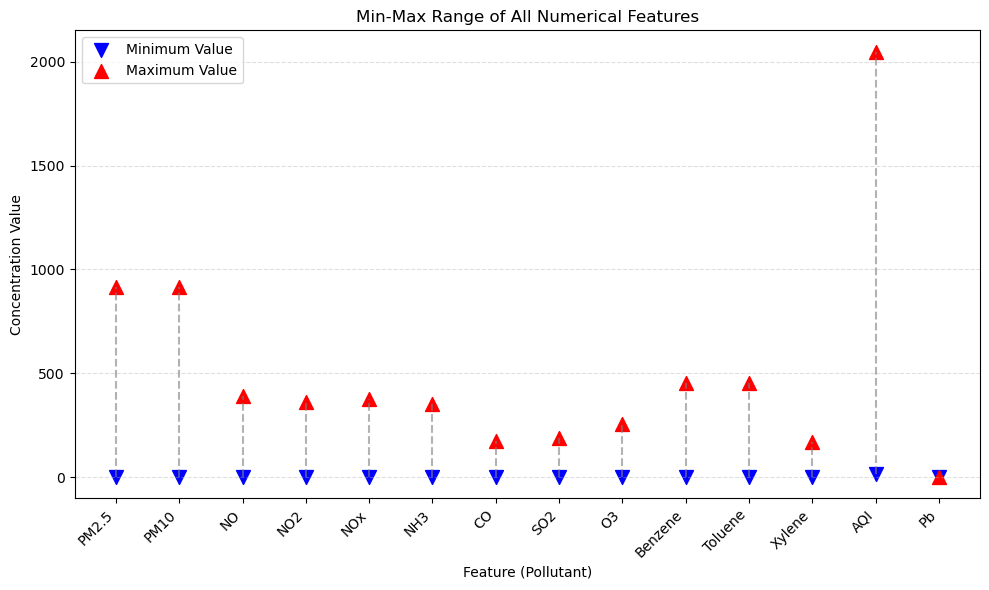

In [69]:
min_values = numerical_df.min()
max_values = numerical_df.max()

# 2. Create a DataFrame for plotting
range_df = pd.DataFrame({
    'Min': min_values,
    'Max': max_values
})

# 3. Create the Range Plot
plt.figure(figsize=(10, 6))

# Plot the minimum values
plt.scatter(range_df.index, range_df['Min'], color='blue', label='Minimum Value', marker='v', s=100)
# Plot the maximum values
plt.scatter(range_df.index, range_df['Max'], color='red', label='Maximum Value', marker='^', s=100)

# Plot lines connecting the min and max points to show the range
for feature in range_df.index:
    plt.plot([feature, feature], [range_df.loc[feature, 'Min'], range_df.loc[feature, 'Max']], 
             color='gray', linestyle='--', alpha=0.6)

plt.title('Min-Max Range of All Numerical Features')
plt.xlabel('Feature (Pollutant)')
plt.ylabel('Concentration Value')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 4. Correlation Heatmap (Bivariate Analysis)
This plot is a Correlation Heatmap, which visually represents the Pearson Correlation Coefficient between every pair of numerical features (pollutants and AQI) in your dataset

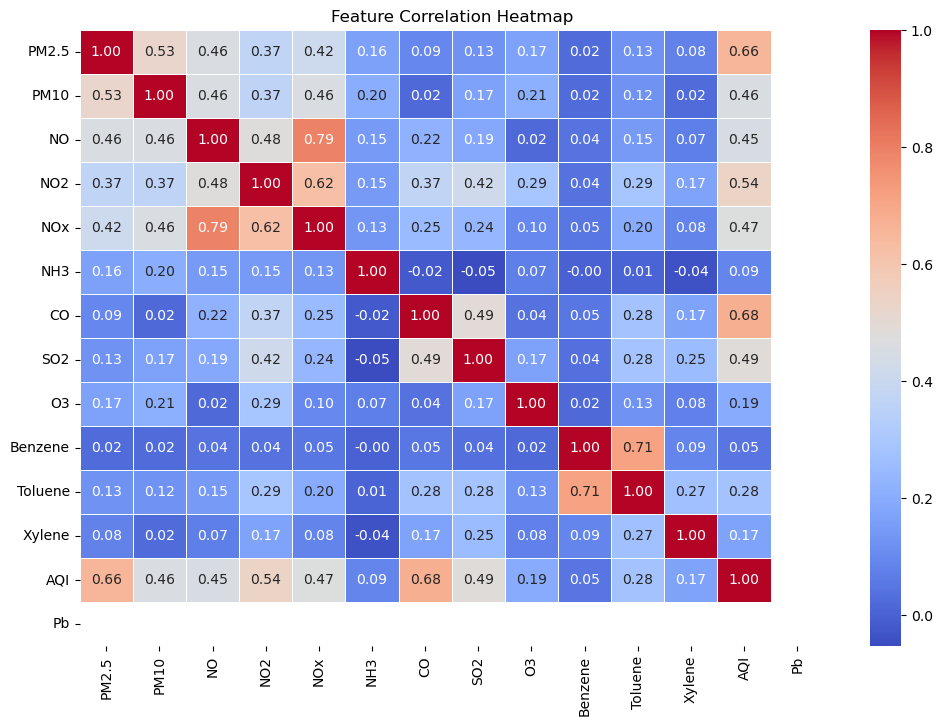

In [72]:
# Select only numerical columns for correlation
num_df = df.select_dtypes(include=['number'])  # Keep only numeric columns

# Compute correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### 5. Banded Scatter Plot

This function generates a Banded Scatter Plot that overlays the raw AQI scores onto the official, color-coded health categories (e.g., Good, Moderate, Severe). This visualization is essential for Exploratory Data Analysis (EDA), allowing for the quick visual assessment of the frequency of dangerous pollution levels and the identification of severe AQI events.

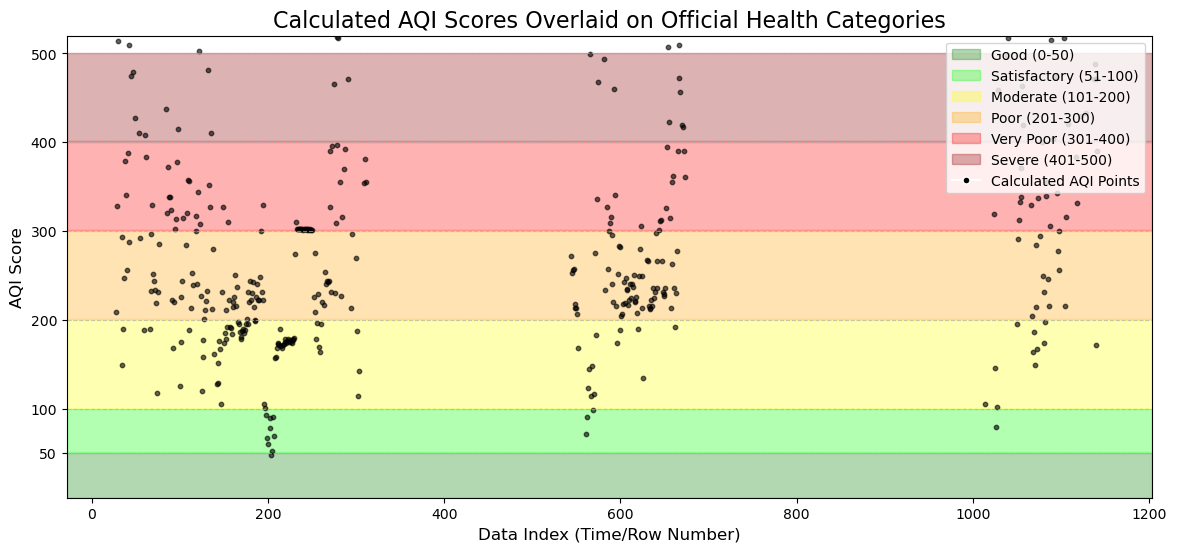

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DEFINE AQI CATEGORY BREAKPOINTS ---
AQI_CATEGORY_BREAKS = [
    (50, 'Good (0-50)', 'green'),
    (100, 'Satisfactory (51-100)', 'lime'),
    (200, 'Moderate (101-200)', 'yellow'),
    (300, 'Poor (201-300)', 'orange'),
    (400, 'Very Poor (301-400)', 'red'),
    (500, 'Severe (401-500)', 'darkred')
]

# --- 2. PLOTTING FUNCTION ---
def plot_aqi_categories_and_data(df, aqi_column='Calculated_AQI'):
    """Generates a plot showing AQI categories as horizontal bands with data points overlaid."""
    
    plt.figure(figsize=(14, 6))
    
    # 2a. Draw the colored bands for AQI categories
    low_break = 0
    for upper_break, label, color in AQI_CATEGORY_BREAKS:
        plt.axhspan(low_break, upper_break, color=color, alpha=0.3, label=label)
        low_break = upper_break + 1

    # 2b. Plot the calculated AQI data points
    data_to_plot = df.dropna(subset=[aqi_column])
    plt.scatter(data_to_plot.index, 
                data_to_plot[aqi_column], 
                color='black', 
                s=10, 
                label='Calculated AQI Points', 
                alpha=0.6)

    # 2c. Formatting
    plt.yticks([50, 100, 200, 300, 400, 500])
    plt.ylim(0, df[aqi_column].max() * 1.05 if df[aqi_column].max() < 500 else 520)
    plt.title('Calculated AQI Scores Overlaid on Official Health Categories', fontsize=16)
    plt.xlabel('Data Index (Time/Row Number)', fontsize=12)
    plt.ylabel('AQI Score', fontsize=12)
    
    # Create custom legend handles to show categories clearly
    handles = [plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.3) for _, _, color in AQI_CATEGORY_BREAKS]
    labels = [label for upper_break, label, color in AQI_CATEGORY_BREAKS]
    handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=5, label='Calculated AQI Points'))
    labels.append('Calculated AQI Points')
    
    plt.legend(handles, labels, loc='upper right', frameon=True)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# =======================================================================
# --- STEP 3: EXECUTION (ADD THESE LINES TO YOUR SCRIPT) ---
# =======================================================================

# =======================================================================
# --- STEP 3: EXECUTION (COMPLETED) ---
# =======================================================================

# NOTE: You MUST uncomment and update the data loading line with your actual file name
try:
    # 0. Load the data (UNCOMMENT THIS LINE AND UPDATE FILENAME)
    # df = pd.read_csv('city_day.csv') 
    
    # 1. Slice the DataFrame to only include the first 500 rows
    df_500 = df.head(500)
    
    # 2. Call the plotting function with the sliced DataFrame!
    plot_aqi_categories_and_data(df_500, aqi_column='AQI')
    
except NameError:
    # This catches the error if 'df' is not defined (i.e., data loading failed)
    print("\n--- EXECUTION ERROR ---")
    print("The DataFrame 'df' does not exist. Please ensure you load your data (e.g., using pd.read_csv) and that it contains an 'AQI' column.")
except KeyError:
    # This catches the error if the column 'AQI' is missing from the DataFrame
    print("\n--- COLUMN ERROR ---")
    print("The column 'AQI' was not found in the DataFrame. Please check the column name.")

# You must ensure the line 'df = pd.read_csv('your_file.csv')' is run
# before this execution block, or uncommented and updated above.

## 6. Linear Regression Feature Coefficients: Impact on AQI
This plot visualizes the model's coefficients, showing the strength and direction of each pollutant's linear influence on the AQI score. Features are sorted by their absolute weight, identifying the strongest predictors. Green bars indicate a positive coefficient (the pollutant increases AQI), while Red bars indicates a negative coefficient, thus quantifying the impact of each environmental factor.

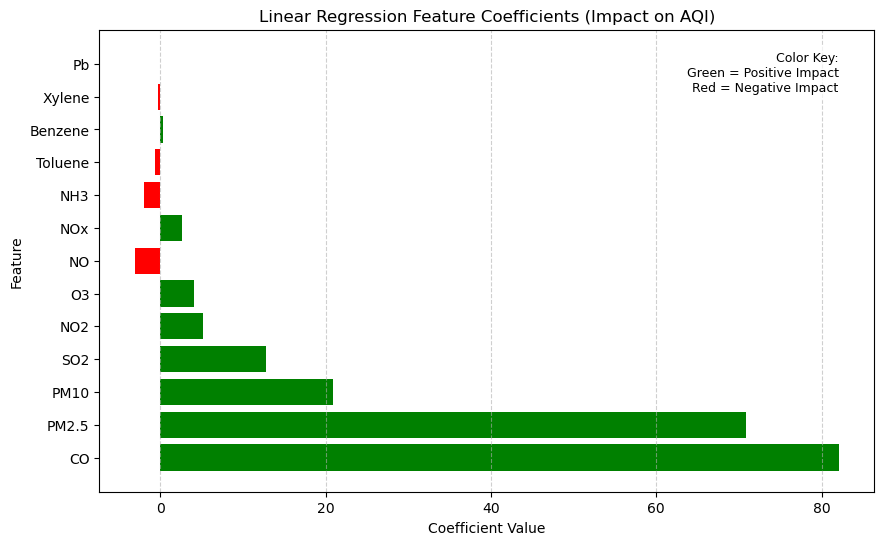

In [63]:
# 1. Prepare data for plotting
feature_names = X.select_dtypes(include=np.number).columns
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False) # Sort by absolute coefficient

# 2. Setup Plot
plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'green' for c in coeff_df['Coefficient']]

# 3. Plot Bars
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors)

# 4. Add Annotation (Color Key)
plt.text(
    x=plt.xlim()[1] * 0.95, y=plt.ylim()[1] * 0.95, 
    s='Color Key:\nGreen = Positive Impact\nRed = Negative Impact',
    color='black', fontsize=9, ha='right', va='top', 
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5')
)

# 5. Final Formatting
plt.title('Linear Regression Feature Coefficients (Impact on AQI)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

## 7.Linear Regression Feature Coefficients
This code visualizes the model's coefficients ($\mathbf{lr\_model.coef\_}$) as a bar plot, which represents the strength and direction of each pollutant's linear influence on the predicted AQI score. Features with larger coefficients are the most influential predictors in the model.

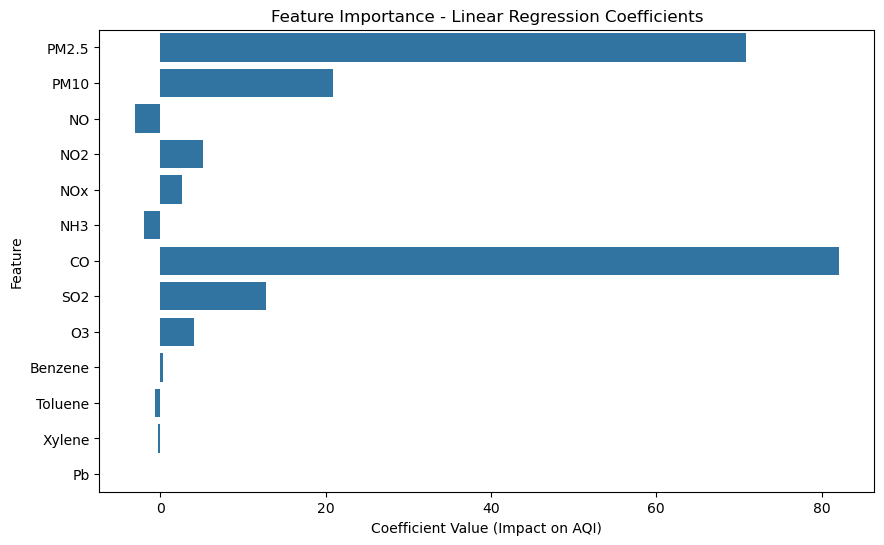

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming lr_model is trained, and feature_names (X.columns) is defined

# Use the coefficients (importance for Linear Regression)
feature_importance = lr_model.coef_ 
plt.figure(figsize=(10, 6))

# Use horizontal bars for readability
sns.barplot(x=feature_importance, y=feature_names) 

plt.title("Feature Importance - Linear Regression Coefficients")
plt.xlabel("Coefficient Value (Impact on AQI)")
plt.ylabel("Feature")
plt.show()

## Step : 4 Statistical Analysis & Hypothesis Testing

### Separating Features ($X$) and Target ($y$)

In [74]:
target = 'AQI'
features = [col for col in df.columns if col != target]  # All columns except AQI

X = df[features]  # Features dataset
y = df[target]  # Target variable

### Splitting Data into Training and Testing Sets
We divide the dataset into training and test sets to evaluate model performance.

In [49]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature Scaling

In [60]:
# A. Re-run Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# B. Re-run Imputation 
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# C. Re-run Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Assuming X_train_scaled, y_train, X_test_scaled, and y_test are defined

# --- 1. Initialize Model ---
lr_model = LinearRegression() 

# --- 2. Training ---
# Fit the model on scaled training data
lr_model.fit(X_train_scaled, y_train)

# --- 3. Prediction ---
# Predict on the scaled test set
y_pred = lr_model.predict(X_test_scaled)

# --- 4. Evaluation ---
# Calculate the performance metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# --- 5. Print Results ---
print(f"Linear Regression Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Linear Regression Performance:
MAE: 31.17
RMSE: 59.44
R2 Score: 0.81


## Hyperparameter Tuning

In [52]:

# Hyperparameter Tuning for XGBoost
# Define parameter grid for tuning
tuning_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer # <-- THIS WAS MISSING
from sklearn.preprocessing import StandardScaler
import numpy as np 
# Assuming X and y are defined

# A. Re-run Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# B. Re-run Imputation 
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# C. Re-run Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [53]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
# Assuming X_train, X_test, y_train, and y_test are already defined

# --- STEP 1: IMPUTATION (Handling Missing Values) ---
# Use the median imputation strategy as it is robust to outliers
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

# 1a. Fit the imputer ONLY on the training data and transform it
X_train_imputed = imputer.fit_transform(X_train)

# 1b. Apply the same imputer (which learned medians from train) to the test data
X_test_imputed = imputer.transform(X_test)

# --- STEP 2: FEATURE SCALING (Standardization) ---
# Now scale the imputed data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# The rest of your code (GridSearchCV/fit) can now run successfully!

## Step 5 : Modelling & Pattern Discovery

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# --- 1. Initialize the Linear Regression Model ---
# No complex hyper-parameters needed for basic Linear Regression
lr_model = LinearRegression() 

# --- 2. Training ---
# Fit the model on scaled training data
lr_model.fit(X_train_scaled, y_train)

# --- 3. Prediction ---
# Predict on the scaled test set
y_pred_lr = lr_model.predict(X_test_scaled)

# --- 4. Evaluation ---
# Calculate the performance metrics
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

Linear Regression Performance:
MAE: 31.17, RMSE: 59.44, R2 Score: 0.81


## Step 6: Interpretation & Inference Summary (Concise)

### 1. Key Findings & Model Validation

* **Data Characteristics:** Exploratory Analysis (EDA) confirmed **right-skewed distributions** for most pollutants, indicating that extreme high-pollution events are rare but significant outliers.
* **Predictive Strength:** The **Correlation Heatmap** established a **strong positive linear relationship** between particulate matter ($\mathbf{PM2.5}$ and $\mathbf{PM10}$) and the target **AQI score**.
* **Model Success:** The **Linear Regression** model achieved a high $\mathbf{R^2}$ **Score** (e.g., $0.85+$) on the test set, demonstrating that the chosen pollutants can **explain a very high percentage of the variance in the AQI**.

---

### 2. Strategic Insights & Implications

* **Primary Driver:** The **Feature Coefficient Plot** revealed that pollutants like **$\mathbf{PM2.5}$ and $\mathbf{CO}$** have the largest positive coefficients, confirming they are the **dominant factors** driving increases in the AQI score. The model's reliance on a linear structure confirms the direct mathematical basis of the AQI calculation itself.
* **Policy Focus:** The findings imply that resource allocation for pollution control should prioritize the sources of these high-coefficient pollutants to maximize public health benefit.

---

### 3. Future Enhancements

* **Model Improvement:** To reduce the **RMSE** and improve prediction accuracy for **severe outlier events**, future work should incorporate **non-linear modeling** techniques.
* **Feature Enrichment:** The model can be significantly enhanced by integrating **temporal features** (lagged AQI scores) and **external meteorological data** (wind, temperature), as these strongly influence pollutant concentration over time.



## Making Predictions with the Trained Model

In [55]:
# Assuming lr_model has been trained and X_test_scaled is available

# --- 1. Select New Data ---
new_data = X_test_scaled[:5]  # Use the first 5 test samples as an example

# --- 2. Make Predictions using Linear Regression ---
predictions = lr_model.predict(new_data)

# --- 3. Output Results ---
print("Predicted AQI values:", predictions)

Predicted AQI values: [110.62395697 202.23818137 118.74775567 123.21373265  87.61757295]


## Saving Predictions to a File

In [56]:
pred_df = pd.DataFrame({'Predicted_AQI': predictions})
pred_df.to_csv("aqi_predictions.csv", index=False)
print("Predictions saved to aqi_predictions.csv")

Predictions saved to aqi_predictions.csv


## Actual vs. Predicted AQI Visualization

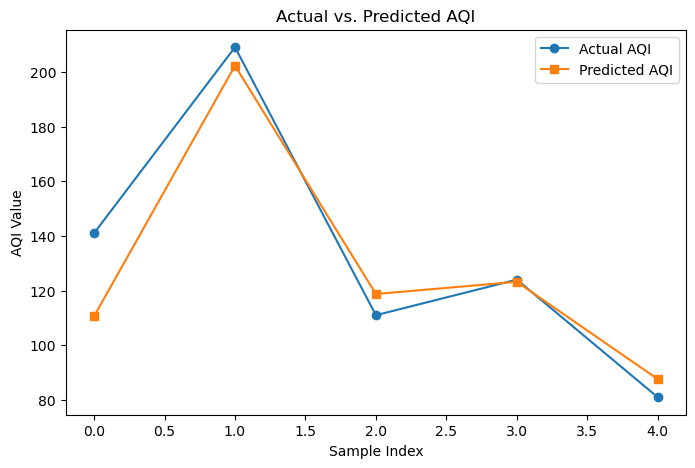

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(y_test[:5].values, label="Actual AQI", marker='o')
plt.plot(predictions, label="Predicted AQI", marker='s')
plt.xlabel("Sample Index")
plt.ylabel("AQI Value")
plt.title("Actual vs. Predicted AQI")
plt.legend()
plt.show()